Name : Mushab Ali

Roll no. : 24

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
X, y = make_regression(100, 1, noise=20, random_state=42, n_targets=1)

#Normalizing data points
X = (X - np.mean(X)) / np.std(X)
y = (y - np.mean(y)) / np.std(y)

X = X.reshape(-1,)
y = y.reshape(-1,)
# X, y

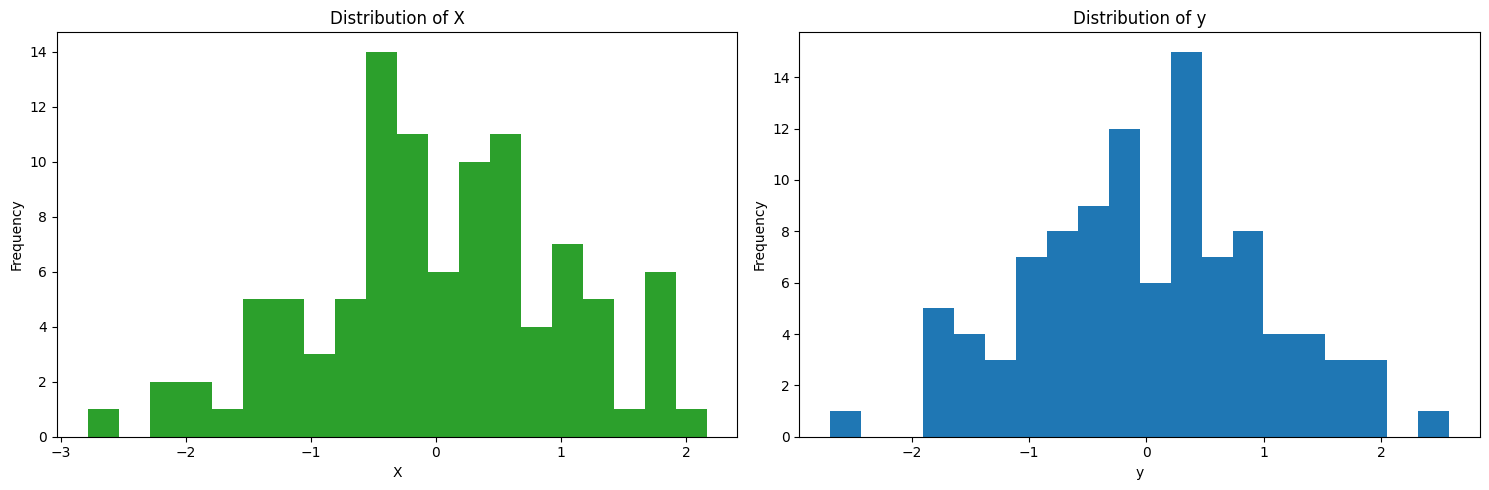

In [240]:
# Plotting distribution
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(X, bins=20, color='tab:green')
ax[0].set_title("Distribution of X")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Frequency")
ax[1].hist(y, bins=20, color='tab:blue')
ax[1].set_title("Distribution of y")
ax[1].set_xlabel("y")
ax[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [242]:
# Applying gradient descent
def gradient_descent(X, y, learning_rate=0.1, num_iterations=1000):

    MSE_list = []
    R2_list = []
    param_0_list = []
    param_1_list = []

    m = len(X)
    param_0 = 0
    param_1 = 0

    for _ in range(num_iterations):
        y_bar = np.mean(y)
        y_pred = param_1 * X + param_0

        loss = y_pred - y
        total = y_bar - y

        MSE = np.mean(loss ** 2)
        MST = np.mean(total ** 2)

        MSE_list.append(MSE)

        R2 = 1 - (MSE / MST)
        R2_list.append(R2)

        grad_0 = np.sum(loss) * (2 / m)
        grad_1 = np.sum(loss * X) * (2 / m)

        prev_param_0 = param_0
        prev_param_1 = param_1

        param_0 -= learning_rate * grad_0
        param_1 -= learning_rate * grad_1

        param_0_list.append(param_0)
        param_1_list.append(param_1)

        if abs(param_0 - prev_param_0) < 1e-6 and abs(param_1 - prev_param_1) < 1e-6:
          break

    return param_1_list, param_0_list, MSE_list, R2_list

In [243]:
G = gradient_descent(X, y, 0.1, 100)
# coefficient retrieval
param_1_list, param_0_list, MSE_list, R2_list = G[0], G[1], G[2], G[3]

fig, ax = plt.subplots(1,2,figsize=(15, 5))
ax1 = ax[0].twinx()

def update(i):
    ax[0].clear()
    ax[0].scatter(i, MSE_list[i], color='tab:red')
    ax[0].plot([0, i],[MSE_list[i], MSE_list[i]], color='tab:red',linestyle='--', label=f'MSE :{MSE_list[i]:.2f}')
    ax[0].plot([i, i],[0, MSE_list[i]], color='tab:green',linestyle='--')
    ax[0].plot(MSE_list, color='tab:red')
    ax[0].set_ylabel('MSE')
    ax[0].legend(loc='center right', bbox_to_anchor=(1, 0.5))

    ax1.clear()
    ax1.scatter(i, R2_list[i], color='tab:blue')
    ax1.plot([0, i],[R2_list[i], R2_list[i]], color='tab:blue',linestyle='--', label=f'R Square :{R2_list[i]:.2f}')
    ax1.plot([i, i],[0, R2_list[i]], color='tab:green', linestyle='--')
    ax1.plot(R2_list, color='tab:blue')
    ax1.set_ylabel('R Square')
    ax1.yaxis.set_label_position('right')
    ax1.legend(loc='center right', bbox_to_anchor=(1, 0.6))

    ax[0].set_xlabel('Iterations')
    ax[0].set_title(f'MSE & R Square vs Iteration\nIteration: {i}')

    ax[1].clear()
    ax[1].scatter(X, y, label='Data Points')
    # plotting linear regression line
    ax[1].plot(X, param_1_list[i] * X + param_0_list[i], color='tab:green', linestyle='--',label=f'Regression')
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('y')
    ax[1].set_title(f'Simple Linear Regression using Gradient Descent')
    ax[1].legend()

    plt.tight_layout()

ani = FuncAnimation(fig, update, frames=len(param_1_list), interval=100, repeat=False)

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

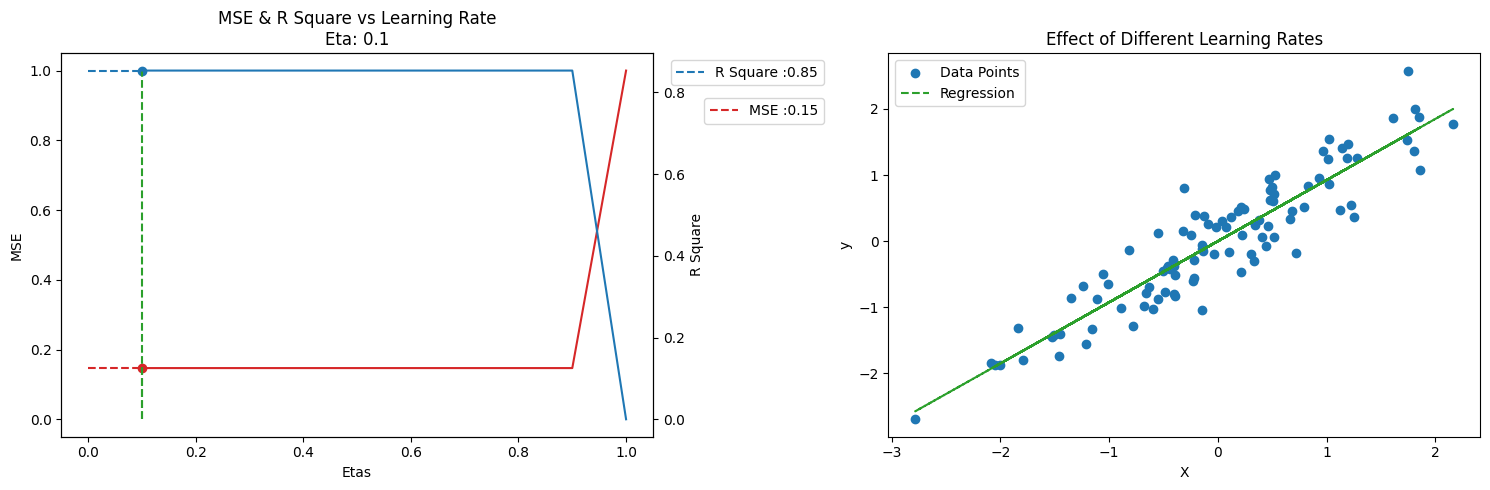

In [244]:
a, b, num, iter = 0.6, 0.1, 10, 1000
# etas = np.linspace(a, b, num)
etas = [0.1, 0.5, 0.6, 0.9, 1]
param_0_eta_list = []
param_1_eta_list = []
MSE_eta_list = []
R2_eta_list = []
for eta in etas:
    grad = gradient_descent(X, y, eta, iter)
    param_1_eta_list.append(grad[0][-1])
    param_0_eta_list.append(grad[1][-1])
    MSE_eta_list.append(grad[2][-1])
    R2_eta_list.append(grad[3][-1])

fig_eta, ax_eta = plt.subplots(1,2,figsize=(15, 5))
ax_eta1 = ax_eta[0].twinx()

def update(i):

    ax_eta[0].clear()
    ax_eta[0].scatter(etas[i], MSE_eta_list[i], color='tab:red')
    ax_eta[0].plot([0, etas[i]],[MSE_eta_list[i], MSE_eta_list[i]], color='tab:red',linestyle='--', label=f'MSE :{MSE_eta_list[i]:.2f}')
    ax_eta[0].plot([etas[i], etas[i]],[0, MSE_eta_list[i]], color='tab:green',linestyle='--')
    ax_eta[0].plot(etas, MSE_eta_list, color='tab:red')
    ax_eta[0].set_ylabel('MSE')
    ax_eta[0].legend(loc='upper right', bbox_to_anchor=(1.3, 0.9))

    ax_eta1.clear()
    ax_eta1.scatter(etas[i], R2_eta_list[i], color='tab:blue')
    ax_eta1.plot([0, etas[i]],[R2_eta_list[i], R2_eta_list[i]], color='tab:blue',linestyle='--', label=f'R Square :{R2_eta_list[i]:.2f}')
    ax_eta1.plot([etas[i], etas[i]],[0, R2_eta_list[i]], color='tab:green', linestyle='--')
    ax_eta1.plot(etas, R2_eta_list, color='tab:blue')
    ax_eta1.set_ylabel('R Square')
    ax_eta1.yaxis.set_label_position('right')
    ax_eta1.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    ax_eta[0].set_xlabel('Etas')
    ax_eta[0].set_title(f'MSE & R Square vs Learning Rate\nEta: {etas[i]}')

    ax_eta[1].clear()
    ax_eta[1].scatter(X, y, label='Data Points')
    ax_eta[1].plot(X, param_1_eta_list[i] * X + param_0_eta_list[i], color='tab:green', linestyle='--',label=f'Regression')
    ax_eta[1].set_xlabel('X')
    ax_eta[1].set_ylabel('y')
    ax_eta[1].set_title('Effect of Different Learning Rates')
    ax_eta[1].legend()

    plt.tight_layout()

ani = FuncAnimation(fig_eta, update, frames=len(param_1_eta_list), interval=100, repeat=False)

HTML(ani.to_jshtml())

In [246]:
a_size, b_size, step,  = 10, 101, 1
Noise, eta = 20, 0.1
data_sizes = np.arange(a_size, b_size, step)
# data_sizes = [100, 200, 300, 400]
param_0_size_list = []
param_1_size_list = []
MSE_size_list = []
R2_size_list = []
X_list = []
y_list = []
for size in data_sizes:

    X_small, y_small = make_regression(size, 1, noise=Noise, random_state=42, n_targets=1)
    X_small = (X_small - np.mean(X_small)) / np.std(X_small)
    y_small = (y_small - np.mean(y_small)) / np.std(y_small)
    X_small = X_small.reshape(-1,)
    y_small = y_small.reshape(-1,)

    grad = gradient_descent(X_small, y_small, eta, 100)

    param_1_size_list.append(grad[0][-1])
    param_0_size_list.append(grad[1][-1])
    MSE_size_list.append(grad[2][-1])
    R2_size_list.append(grad[3][-1])
    X_list.append(X_small)
    y_list.append(y_small)

fig_size, ax_size = plt.subplots(1,2,figsize=(15, 5))
ax_size1 = ax_size[0].twinx()

def update(i):

    ax_size[0].clear()
    ax_size[0].scatter(data_sizes[i], MSE_size_list[i], color='tab:red')
    ax_size[0].plot([0, data_sizes[i]],[MSE_size_list[i], MSE_size_list[i]], color='tab:red',linestyle='--', label=f'MSE :{MSE_size_list[i]:.2f}')
    ax_size[0].plot([data_sizes[i], data_sizes[i]],[0, MSE_size_list[i]], color='tab:green',linestyle='--')
    ax_size[0].plot(data_sizes, MSE_size_list, color='tab:red')
    ax_size[0].set_ylabel('MSE')
    ax_size[0].legend(loc='upper right', bbox_to_anchor=(1.3, 0.9))

    ax_size1.clear()
    ax_size1.scatter(data_sizes[i], R2_size_list[i], color='tab:blue')
    ax_size1.plot([0, data_sizes[i]],[R2_size_list[i], R2_size_list[i]], color='tab:blue',linestyle='--', label=f'R Square :{R2_size_list[i]:.2f}')
    ax_size1.plot([data_sizes[i], data_sizes[i]],[0, R2_size_list[i]], color='tab:green', linestyle='--')
    ax_size1.plot(data_sizes, R2_size_list, color='tab:blue')
    ax_size1.set_ylabel('R Square')
    ax_size1.yaxis.set_label_position('right')
    ax_size1.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    ax_size[0].set_xlabel('Data Sizes')
    ax_size[0].set_title(f'MSE & R Square vs Data Size\nData Size: {data_sizes[i]}')

    ax_size[1].clear()
    ax_size[1].scatter(X_list[i], y_list[i], label='Data Points')
    ax_size[1].plot(X_list[i], param_1_size_list[i] * X_list[i] + param_0_size_list[i], color='tab:green', linestyle='--',label=f'Regression')
    ax_size[1].set_xlabel('X')
    ax_size[1].set_ylabel('y')
    ax_size[1].set_title('Effect of Different Data Sizes')
    ax_size[1].legend()

    plt.tight_layout()

ani = FuncAnimation(fig_size, update, frames=len(param_1_size_list), interval=100, repeat=False)

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.